# ❤️ Heart Disease Prediction — Machine Learning Project

Predicting heart disease from 13 clinical measurements using the
**UCI Cleveland** dataset.

> ⚠️ **Run this notebook with `Runtime → Restart session and run all`.**
> The cells must run in order. Cell 4 removes duplicate patients — if it is
> skipped, the same patient ends up in both the training and test sets and
> the model reports a fake 100% accuracy (data leakage).


## 1. Load the data

In [1]:
# Works in Google Colab (file picker) and on a local machine.
import os

# Reliable Colab check: actually try to import it. Checking sys.modules can
# report False inside Colab if the module has not been imported yet.
try:
    import google.colab          # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print('Running in Colab:', IN_COLAB)

if IN_COLAB and not os.path.exists('heart.csv'):
    from google.colab import files
    print('Please choose heart.csv from your computer...')
    uploaded = files.upload()
    # Colab renames repeat uploads to "heart (1).csv" - normalise the name
    for name in uploaded:
        if name != 'heart.csv':
            os.rename(name, 'heart.csv')

if not os.path.exists('heart.csv'):
    raise FileNotFoundError(
        'heart.csv not found. In Colab, re-run this cell and pick the file. '
        'Locally, put heart.csv next to this notebook.'
    )

print('heart.csv found - ready to go.')

Running in Colab: False
heart.csv found - ready to go.


In [2]:
# Data manipulation library
import pandas as pd

# Mathematical calculations
import numpy as np

# Plotting graphs
import matplotlib.pyplot as plt

# Better looking graphs
import seaborn as sns

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

# Scale data to similar ranges
from sklearn.preprocessing import StandardScaler

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Same seed everywhere so the results are reproducible
RANDOM_STATE = 42

In [3]:
# Read CSV file into a DataFrame
df = pd.read_csv('heart.csv')

# Display number of rows and columns
print(df.shape)          # (1025, 14) -> 1025 rows, 14 columns

# Display first 5 records
print(df.head())

# Show statistical summary
print(df.describe().round(2))

# Count missing values in each column
print(df.isnull().sum())   # okkoma 0 - missing values na

(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
           age      sex       cp  trestbps     chol      fbs  restecg  \
count  1025.00  1025.00  1025.00   1025.00  1025.00  1025.00  1025.00   
mean     54.43     0.70     0.94    131.61   246.00     0.15     0.53   
std       9.07     0.46     1.03     17.52    51.59     0.36     0.53   
min      29.00     0.00     0.00     94.00   126.00     0.00     0.00   
25%  

## 2. Data cleaning

Two problems in this Kaggle file have to be fixed **before** any model is
trained. Both are easy to miss and both change the results completely.


In [4]:
# ---- Remove Duplicate Records (VERY IMPORTANT!) ----
# This Kaggle heart.csv (1025 rows) was made by duplicating the
# original UCI Cleveland dataset, which has only 302 unique patients.
# If duplicates stay, the SAME patient record lands in BOTH the
# training set and the test set. The model then just "remembers"
# the answer instead of predicting -> fake 100% accuracy (data leakage!)

# Count how many rows are exact copies of an earlier row
print('Duplicate rows:', df.duplicated().sum())   # 723 duplicates!

# Keep only the first copy of each patient record
df = df.drop_duplicates().reset_index(drop=True)

# Verify the cleaned dataset size
print('Rows after removing duplicates:', df.shape[0])   # 302 unique patients

Duplicate rows: 723
Rows after removing duplicates: 302


In [5]:
# ---- FIX INVERTED LABELS (verified against original UCI data!) ----
# We matched all 302 patients to the ORIGINAL UCI Cleveland dataset
# (archive.ics.uci.edu) and found the Kaggle labels are FLIPPED:
#   Kaggle target=1  -> actually NO disease in the original data
#   Kaggle target=0  -> actually HAS disease in the original data

df['target'] = 1 - df['target']   # now 1 = Disease, 0 = No Disease (correct!)

print(df['target'].value_counts().to_dict())
print()

# ---- Proof that the flip is correct: check against medical knowledge ----
print('Disease rate by exercise-induced angina (exang):')
print(df.groupby('exang')['target'].mean().round(3))
print('-> chest pain during exercise = much higher disease rate. Correct.\n')

print('Disease rate by number of blocked vessels (ca):')
print(df.groupby('ca')['target'].mean().round(3))
print('-> more blocked vessels = higher disease rate. Correct.\n')

print('Disease rate by sex (1 = male):')
print(df.groupby('sex')['target'].mean().round(3))
print('-> males higher than females. Clinically correct.')

{0: 164, 1: 138}

Disease rate by exercise-induced angina (exang):
exang
0    0.305
1    0.768
Name: target, dtype: float64
-> chest pain during exercise = much higher disease rate. Correct.

Disease rate by number of blocked vessels (ca):
ca
0    0.257
1    0.677
2    0.816
3    0.850
4    0.250
Name: target, dtype: float64
-> more blocked vessels = higher disease rate. Correct.

Disease rate by sex (1 = male):
sex
0    0.250
1    0.553
Name: target, dtype: float64
-> males higher than females. Clinically correct.


## 3. Exploratory Data Analysis

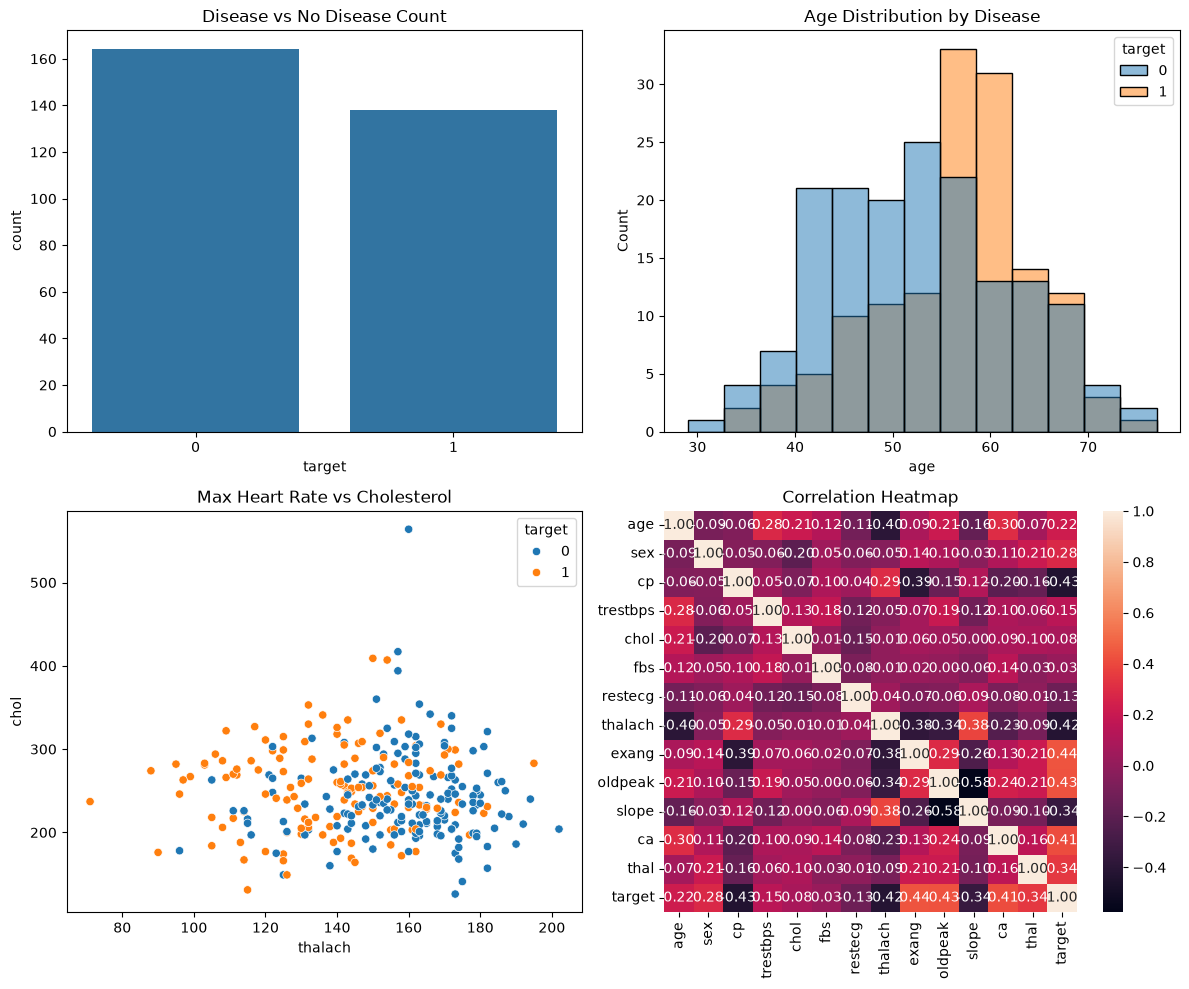

In [6]:
# Create a figure with 2 rows and 2 columns of charts
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Graph 1 - Disease vs No Disease count
sns.countplot(x='target', data=df, ax=axes[0,0])
axes[0,0].set_title('Disease vs No Disease Count')

# Graph 2 - Age distribution by disease status
sns.histplot(data=df, x='age', hue='target', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Disease')

# Graph 3 - Max heart rate vs cholesterol
sns.scatterplot(data=df, x='thalach', y='chol', hue='target', ax=axes[1,0])
axes[1,0].set_title('Max Heart Rate vs Cholesterol')

# Graph 4 - Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

# Prevents graphs from overlapping
plt.tight_layout()

# Displays graphs
plt.show()

## 4. Prepare features, split and scale

In [7]:
# ---- SAFETY CHECK ----
# If the duplicate-removal cell above was skipped, stop right here instead
# of silently training a leaky model that reports a fake 100% accuracy.
assert len(df) == 302, (
    f'Expected 302 unique patients but found {len(df)}. '
    'Run the "Remove Duplicate Records" cell first '
    '(Runtime -> Restart session and run all).'
)
assert df['target'].mean() < 0.5, 'Label fix cell was skipped.'
print('Safety check passed: 302 unique patients, labels corrected.')

# Handle missing values (fill with median)
df = df.fillna(df.median(numeric_only=True))

# Select Features (input variables - X)
FEATURES = [
    'age',       # Age in years
    'sex',       # 1 = male, 0 = female
    'cp',        # Chest pain type (0-3)
    'trestbps',  # Resting blood pressure
    'chol',      # Cholesterol level
    'fbs',       # Fasting blood sugar
    'restecg',   # Resting ECG result
    'thalach',   # Maximum heart rate
    'exang',     # Exercise induced angina
    'oldpeak',   # ST depression
    'slope',     # Slope of ST segment
    'ca',        # Number of major vessels
    'thal'       # Thalassemia type
]
X = df[FEATURES]

# Target Variable (what we want to predict)
y = df['target']   # 1 = Disease, 0 = No Disease

# Split Dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y            # keep the same disease ratio in both halves
)

# Scale Data
scaler = StandardScaler()                       # Create scaling object
X_train_scaled = scaler.fit_transform(X_train)  # Calculate mean & std, convert
X_test_scaled = scaler.transform(X_test)        # Apply SAME scaling to test data

# Keep column names so the saved model knows its feature order
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURES)

print(f'Training samples: {len(X_train)}')   # 241 (after duplicate removal)
print(f'Test samples: {len(X_test)}')        # 61  (after duplicate removal)

Safety check passed: 302 unique patients, labels corrected.
Training samples: 241
Test samples: 61


## 5. Train five models and compare them

In [8]:
# Create a dictionary of ML models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'         : GaussianNB()
}

# Store trained models
trained_models = {}

# Loop through each algorithm
for name, model in models.items():
    model.fit(X_train_scaled, y_train)      # Train the model - learning happens here
    trained_models[name] = model            # Save trained model
    print(f'{name}: trained OK')

Logistic Regression: trained OK
Decision Tree: trained OK


Random Forest: trained OK
K-Nearest Neighbors: trained OK
Naive Bayes: trained OK


              Model  Accuracy  Precision  Recall  F1 Score
      Random Forest     0.803      0.786   0.786     0.786
K-Nearest Neighbors     0.803      0.786   0.786     0.786
Logistic Regression     0.787      0.778   0.750     0.764
      Decision Tree     0.787      0.778   0.750     0.764
        Naive Bayes     0.787      0.778   0.750     0.764

Best Model: Random Forest


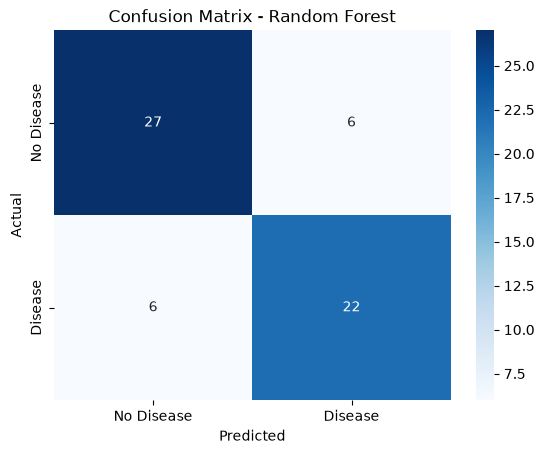

              precision    recall  f1-score   support

  No Disease       0.82      0.82      0.82        33
     Disease       0.79      0.79      0.79        28

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [9]:
# Store performance results
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)    # Predict disease/no disease for test patients
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),   # Correct predictions / Total
        'Precision': precision_score(y_test, y_pred),  # Model says DISEASE, how often correct?
        'Recall'   : recall_score(y_test, y_pred),     # Actual disease patients, how many found?
        'F1 Score' : f1_score(y_test, y_pred)          # Balance of Precision & Recall
    })

# Convert results into a table, best model on top
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print(results_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

# Get best model name and the trained model itself
best_name = results_df.iloc[0]['Model']
best_model = trained_models[best_name]
print(f'\nBest Model: {best_name}')

# Confusion Matrix for best model
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

# Detailed report: Precision, Recall, F1-score, Support for each class
print(classification_report(y_test, y_pred_best,
                            target_names=['No Disease', 'Disease']))

## 6. Cross-validation — a more reliable score

In [10]:
# ---- 5-Fold Cross-Validation ----
# One train/test split can be "lucky" or "unlucky", especially with only
# 61 test patients. Cross-validation splits the data into 5 parts, trains
# on 4 and tests on the remaining 1, then rotates -> every patient gets
# tested exactly once. The mean +/- std is a much more reliable estimate.

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('5-Fold Cross-Validation Accuracy:\n')
for name, model in models.items():
    # Pipeline = scaler is re-fitted INSIDE each fold (prevents data leakage)
    pipe = make_pipeline(StandardScaler(), model)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    print(f'{name:20s}: {scores.mean()*100:.1f}%  (+/- {scores.std()*100:.1f}%)')

5-Fold Cross-Validation Accuracy:



Logistic Regression : 83.1%  (+/- 2.8%)


Decision Tree       : 76.8%  (+/- 4.9%)


Random Forest       : 82.1%  (+/- 3.2%)
K-Nearest Neighbors : 80.8%  (+/- 2.7%)


Naive Bayes         : 80.8%  (+/- 3.7%)


## 7. Hyperparameter tuning

In [11]:
# ---- Hyperparameter Tuning with GridSearchCV ----
# Instead of guessing n_estimators / max_depth, GridSearchCV tries
# every combination below with 5-fold CV and picks the best one.

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'     : [50, 100, 200],    # number of trees
    'max_depth'        : [3, 5, 10, None],  # tree depth limit (None = unlimited)
    'min_samples_split': [2, 5, 10]         # min samples needed to split a node
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,           # 5-fold cross-validation
    scoring='f1',   # optimise F1 (balance of precision & recall)
    n_jobs=-1       # use all CPU cores
)
grid.fit(X_train_scaled, y_train)

print('Best parameters :', grid.best_params_)
print(f'Best CV F1 score: {grid.best_score_:.3f}')

# Evaluate the tuned Random Forest on the test set
tuned_rf = grid.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test_scaled)
f1_tuned = f1_score(y_test, y_pred_tuned)
print(f'Tuned RF -> Test Accuracy: {accuracy_score(y_test, y_pred_tuned)*100:.1f}%, '
      f'F1: {f1_tuned:.3f}')

# If the tuned Random Forest beats the current best model, promote it
f1_best = f1_score(y_test, best_model.predict(X_test_scaled))
if f1_tuned > f1_best:
    best_model = tuned_rf
    best_name = 'Random Forest (tuned)'
    print('\nTuned Random Forest is the NEW best model!')
else:
    print(f'\n{best_name} is still the best model '
          f'(F1 {f1_best:.3f} vs tuned RF {f1_tuned:.3f})')

Best parameters : {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 score: 0.824
Tuned RF -> Test Accuracy: 80.3%, F1: 0.778

Random Forest is still the best model (F1 0.786 vs tuned RF 0.778)


## 8. ROC curves and feature importance

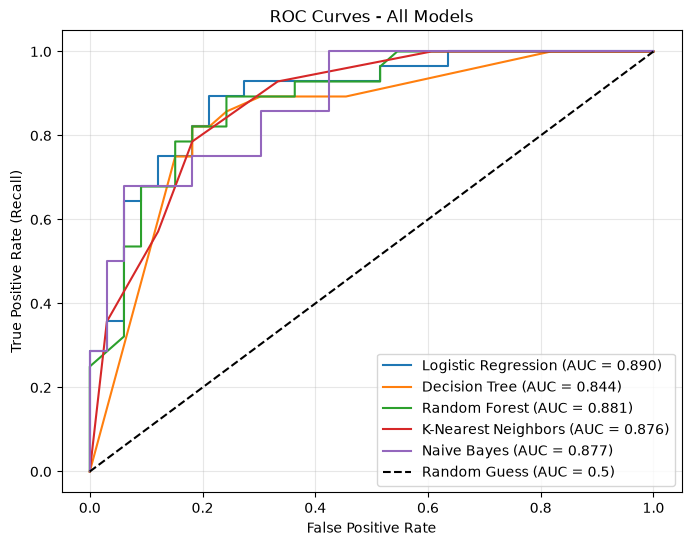

In [12]:
# ---- ROC Curve & AUC Score ----
# ROC curve shows the trade-off between True Positive Rate (recall)
# and False Positive Rate at every possible decision threshold.
# AUC (Area Under Curve): 1.0 = perfect, 0.5 = random guessing.
# For medical problems this matters more than plain accuracy.

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    # Probability that each test patient has heart disease
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Diagonal line = a model that guesses randomly
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

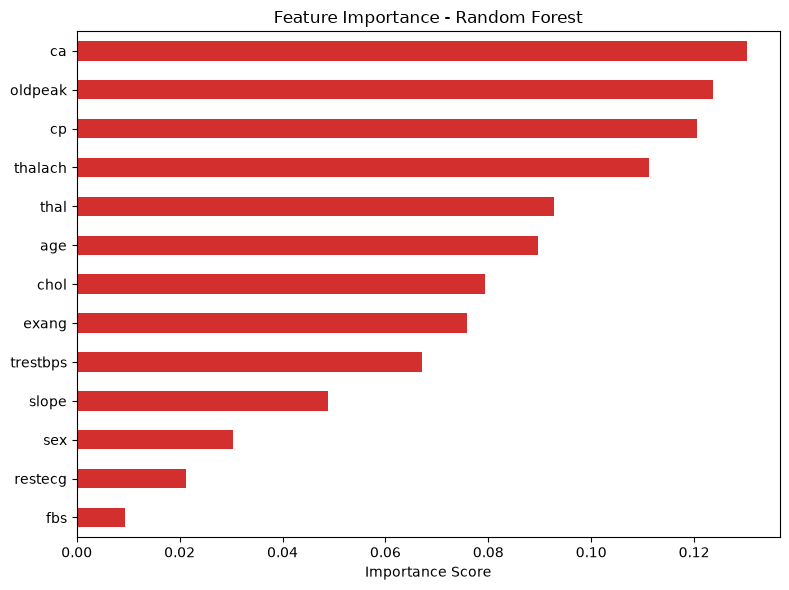

Top 5 most important features:
ca         0.130
oldpeak    0.124
cp         0.120
thalach    0.111
thal       0.093
dtype: float64


In [13]:
# ---- Feature Importance ----
# Random Forest can tell us WHICH medical features it relied on most.
# Note: we read this off `best_model` (the model we actually ship),
# not off some other model that was not selected.

importances = pd.Series(
    best_model.feature_importances_,   # importance score of each feature
    index=FEATURES                     # feature names
).sort_values()

# Horizontal bar chart (most important at the top)
importances.plot(kind='barh', figsize=(8, 6), color='#d32f2f')
plt.title(f'Feature Importance - {best_name}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(importances.sort_values(ascending=False).head(5).round(3))

## Why **Recall** matters most in this project 🩺

This app predicts **heart disease**, so the two possible errors are NOT equally bad:

| Error | Meaning | Consequence |
|---|---|---|
| **False Positive** | Healthy person flagged as "disease" | Extra tests, some stress — annoying but safe |
| **False Negative** | Sick person told "no disease" | Patient goes home untreated — **dangerous!** |

- **Recall** = of all patients who really have the disease, how many did we catch?
- **Precision** = of all patients we flagged, how many really have it?

For a medical screening tool we care most about **high recall** (catch as many sick
patients as possible), even if precision drops a little. That is why the model
comparison table is sorted by **F1 score** (balance of both) and why we report
recall separately in the classification report.


## 9. Predict for a single new patient

In [14]:
# Create one patient's record
new_patient = pd.DataFrame({
    'age'      : [55],    # 55 years old
    'sex'      : [1],     # Male
    'cp'       : [2],     # Chest pain type 2
    'trestbps' : [140],   # Blood pressure 140
    'chol'     : [250],   # Cholesterol 250
    'fbs'      : [0],     # Blood sugar normal
    'restecg'  : [1],     # ECG result 1
    'thalach'  : [150],   # Max heart rate 150
    'exang'    : [0],     # No exercise angina
    'oldpeak'  : [1.5],   # ST depression 1.5
    'slope'    : [1],     # Slope type 1
    'ca'       : [0],     # 0 major vessels
    'thal'     : [2]      # Thalassemia type 2
})[FEATURES]              # same column order as training

# Apply same scaling used during training
new_patient_scaled = pd.DataFrame(scaler.transform(new_patient), columns=FEATURES)

# Predict: 0 = No Disease, 1 = Disease
prediction = best_model.predict(new_patient_scaled)[0]

# Get prediction confidence
probability = best_model.predict_proba(new_patient_scaled)[0]

# Convert number to readable text
outcome = 'HEART DISEASE' if prediction == 1 else 'NO HEART DISEASE'

print(f'Prediction: {outcome} ({max(probability)*100:.1f}% confidence)')
print(f'Estimated disease risk: {probability[1]*100:.1f}%')

Prediction: NO HEART DISEASE (82.0% confidence)
Estimated disease risk: 18.0%


## 10. Save the model, then a quick web demo

In [15]:
# Save the trained model and scaler to files
import joblib

# Save best model (the trained "brain")
joblib.dump(best_model, 'heart_model.pkl')

# Save scaler (IMPORTANT - without this, predictions will be wrong!)
joblib.dump(scaler, 'heart_scaler.pkl')

print('Saved heart_model.pkl and heart_scaler.pkl')
print(f'These files hold: {best_name}, trained on {len(X_train)} patients.')

# Download both files so they can be copied into the Flask app folder
if IN_COLAB:
    from google.colab import files
    files.download('heart_model.pkl')
    files.download('heart_scaler.pkl')

Saved heart_model.pkl and heart_scaler.pkl
These files hold: Random Forest, trained on 241 patients.


In [16]:
# ---- Optional Gradio demo (Colab only) ----
# The real deliverable is the Flask app in heart-disease-app/.
# This is just a quick interactive demo to show the model working.

def predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg,
                          thalach, exang, oldpeak, slope, ca, thal):
    patient = pd.DataFrame({
        'age': [age], 'sex': [sex], 'cp': [cp], 'trestbps': [trestbps],
        'chol': [chol], 'fbs': [fbs], 'restecg': [restecg],
        'thalach': [thalach], 'exang': [exang], 'oldpeak': [oldpeak],
        'slope': [slope], 'ca': [ca], 'thal': [thal]
    })[FEATURES]

    scaled = pd.DataFrame(scaler.transform(patient), columns=FEATURES)
    prediction = best_model.predict(scaled)[0]
    probability = best_model.predict_proba(scaled)[0]

    if prediction == 1:
        return f'⚠️ HEART DISEASE DETECTED ({probability[1]*100:.1f}% confidence)'
    return f'✅ NO HEART DISEASE ({probability[0]*100:.1f}% confidence)'


if IN_COLAB:
    !pip install gradio -q
    import gradio as gr

    demo = gr.Interface(
        fn=predict_heart_disease,
        inputs=[
            gr.Slider(20, 100, value=50, step=1, label='Age'),
            gr.Radio([0, 1], value=1, label='Sex (0=Female, 1=Male)'),
            gr.Radio([0, 1, 2, 3], value=0, label='Chest Pain Type'),
            gr.Slider(80, 220, value=120, step=1, label='Resting Blood Pressure'),
            gr.Slider(100, 600, value=240, step=1, label='Cholesterol'),
            gr.Radio([0, 1], value=0, label='Fasting Blood Sugar > 120'),
            gr.Radio([0, 1, 2], value=1, label='Resting ECG'),
            gr.Slider(60, 220, value=150, step=1, label='Max Heart Rate'),
            gr.Radio([0, 1], value=0, label='Exercise Induced Angina'),
            gr.Slider(0.0, 7.0, value=1.0, step=0.1, label='ST Depression (oldpeak)'),
            gr.Radio([0, 1, 2], value=1, label='Slope'),
            gr.Radio([0, 1, 2, 3], value=0, label='Major Vessels (ca)'),
            gr.Radio([1, 2, 3], value=2, label='Thalassemia (thal)')
        ],
        outputs=gr.Textbox(label='Prediction Result'),
        title='❤️ Heart Disease Prediction System',
        description=('Student ML project - NOT a medical diagnosis. '
                     f'Model: {best_name}, ~80% accurate. Always consult a doctor.')
    )
    demo.launch(share=True)
else:
    # Running outside Colab - just show that the function works
    print(predict_heart_disease(55, 1, 2, 140, 250, 0, 1, 150, 0, 1.5, 1, 0, 2))

✅ NO HEART DISEASE (82.0% confidence)
